# 1. 数据集

(10000, 3)
shape of moons:  (10000, 2)


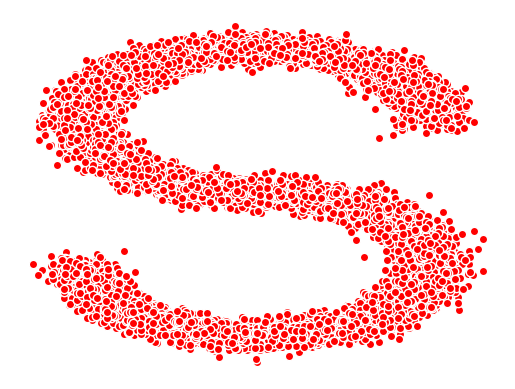

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_s_curve
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

s_curve = make_s_curve(10**4, noise=0.1)[0]
print(s_curve.shape)
s_curve = s_curve[:, [0, 2]] / 10.0

print("shape of moons: ", s_curve.shape)

data = s_curve.T
fig, ax = plt.subplots()
ax.scatter(*data, color="red", edgecolor="white")

ax.axis("off")

dataset = torch.Tensor(s_curve).float()

# 2. 确定超参数值

In [16]:
nums_step = 100

# 指定 beta 范围
betas = torch.linspace(-6, 6, nums_step)
betas = torch.sigmoid(betas) * (0.5e-2 - 1e-5) + 1e-5

# 计算 alpha, alpha_prod, alpha_prod_prev, alpha_bar_sqrt等变量的值
alphas = 1 - betas
alphas_bar = torch.cumprod(alphas, 0)
alphas_bar_p = torch.cat([torch.tensor([1]).float(), alphas_bar[:-1]], 0) # 直接第0项设为1, p表示previous
alphas_bar_sqrt = torch.sqrt(alphas_bar).to(device)

one_minus_alphas_bar_log = torch.log(1 - alphas_bar)
one_minus_alphas_bar_sqrt = torch.sqrt(1 - alphas_bar).to(device)

assert alphas.shape == alphas_bar.shape == alphas_bar_p.shape == alphas_bar_sqrt.shape == one_minus_alphas_bar_log.shape == one_minus_alphas_bar_sqrt.shape

print("all the same shape: ", alphas.shape)

all the same shape:  torch.Size([100])


# 3. 确定扩散过程任意时刻的采样值

In [6]:
def q_x(x_0, t):
    # 可以基于x[0]得到任意时刻t的x[t]

    noise = torch.randn_like(x_0)
    alphas_t_sqrt = alphas_bar_sqrt[t]
    alphas_1_m_t_sqrt = one_minus_alphas_bar_sqrt[t]

    return (alphas_t_sqrt * x_0 + alphas_1_m_t_sqrt * noise)

# 4. 可视化扩散过程

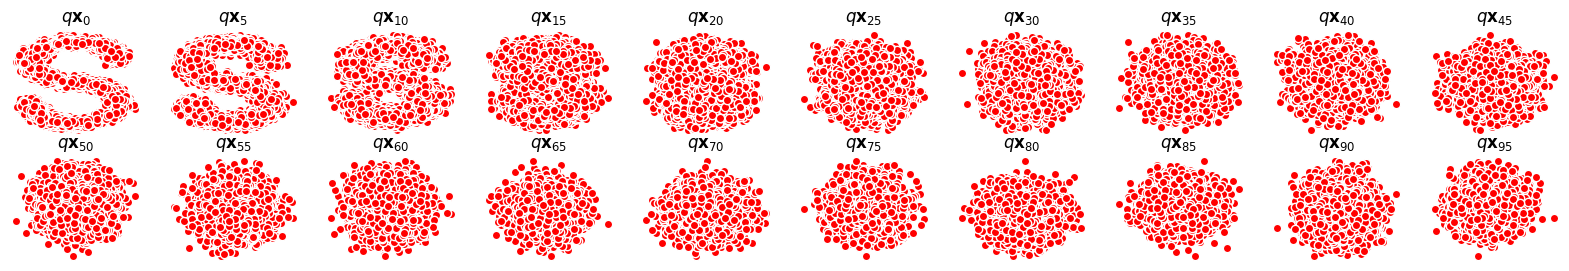

In [7]:
num_shows = 20

fig, axs = plt.subplots(2, 10, figsize=(20, 3))
plt.rc("text", color="blue")

# 共有10000个点，每个点包含两个坐标
# 生成100步以内每隔5步加噪声后的图像
for i in range(num_shows):
    j = i // 10
    k = i % 10
    q_i = q_x(dataset, torch.tensor([i*nums_step // num_shows])) # 生成t时刻的采样数据
    axs[j, k].scatter(q_i[:, 0], q_i[:, 1], color="red", edgecolor="white")

    axs[j, k].set_axis_off()
    axs[j, k].set_title('$q{\mathbf{x}_{'+str(i * nums_step // num_shows)+'}}$')


# 5. 逆扩散过程

In [8]:
import torch
import torch.nn as nn

class MLPDiffusion(nn.Module):
    def __init__(self, n_steps, num_units=128):
        super(MLPDiffusion, self).__init__()
        
        self.linears = nn.ModuleList([
            nn.Linear(2, num_units),
            nn.ReLU(),
            nn.Linear(num_units, num_units),
            nn.ReLU(),
            nn.Linear(num_units, num_units),
            nn.ReLU(),
            nn.Linear(num_units, 2),
        ])

        self.step_embeddings = nn.ModuleList([
            nn.Embedding(n_steps, num_units),
            nn.Embedding(n_steps, num_units),
            nn.Embedding(n_steps, num_units),
        ])

    def forward(self, x_0, t):
        x = x_0
        for idx, embedding_layer in enumerate(self.step_embeddings):
            # print("t shape: ", t.shape)
            # print("embedding_layer weight shape: ", embedding_layer.weight.shape)
            # print("x shape before embedding: ", x.shape)
            t_embedding = embedding_layer(t)
            # print("t_embedding shape: ", t_embedding.shape)
            # print(f"t_embedding: {t_embedding}")
            x = self.linears[2 * idx](x)
            x += t_embedding
            x = self.linears[2 * idx + 1](x)

        x = self.linears[-1](x)

        return x


# 6. 编写训练的损失函数

In [9]:
def diffusion_loss_fn(model, x_0, alphas_bra_sqrt, one_minus_alphas_bar_sqrt, n_steps, device):
    # 对任意时刻t采样计算loss
    batch_size = x_0.shape[0]

    # 随机采样一个时刻t, 为了提高训练效率，这里确保t不重复
    #
    t = torch.randint(0, n_steps, size = (batch_size // 2, )).to(device)
    t = torch.cat([t, n_steps-1-t], dim=0)
    t = t.unsqueeze(-1)

    # x_0系数
    a = alphas_bar_sqrt[t]

    # eps系数
    aml = one_minus_alphas_bar_sqrt[t]

    # 生成随机噪音 eps
    e = torch.randn_like(x_0)

    # 构建模型输入
    x = x_0 * a + e * aml
    
    # print("x shape: ", x.shape)
    # print("t shape: ", t.shape)
    # 送入模型，得到t时刻的随机噪声预测值
    output = model(x, t.squeeze(-1))
    
    # 与真实噪声一起计算误差，求平均值
    return (e - output).square().mean()

# 7. 编写逆扩散采样函数

In [18]:
def p_sample_loop(model, shape, n_steps, betas, one_minus_alphas_bar_sqrt):
    # 从 x[t] 恢复 x[t-1], x[t-2] ..., x[0]

    cur_x = torch.randn(shape).to(device)
    x_seq = [cur_x]
    for i in reversed(range(n_steps)):
         cur_x = p_sample(model, cur_x, i, betas, one_minus_alphas_bar_sqrt)
         x_seq.append(cur_x)

    return x_seq

def p_sample(model, x, t, betas, one_minus_alphas_bar_sqrt):
    # 从 x[t] 采样 t 时刻的重构值

    t = torch.Tensor([t]).int().to(device)

    # print("type of betas: ", type(betas))
    # print("type of one_minus_alphas_bar_sqrt: ", type(one_minus_alphas_bar_sqrt))
    
    coeff = betas[t] / one_minus_alphas_bar_sqrt[t]

    eps_theta = model(x, t)

    mean = (1 / (1 - betas[t].sqrt()) * (x - coeff * eps_theta))

    x = torch.randn_like(x)
    sigma_t = betas[t].sqrt()

    sample = mean + sigma_t * x

    return (sample)

# 8. 训练模型

In [ ]:
seed = 1234

class EMA():
    # 参数平滑器
    def __init__(self, mu=0.01):
        self.mu = mu
        self.shadow = {}

    def register(self, name, val):
        self.shadow[name] = val.clone()

    def __call__(self, name, x):
        assert name in self.shadow
        new_average = (1.0 - self.mu) * x + self.mu * self.shadow[name]
        self.shadow[name] = new_average.clone()
        return new_average

print("Training model...")

"""
ema = EMA(0.5)
for
"""
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 128
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
num_epochs = 4000
plt.rc("text", color="blue")

model = MLPDiffusion(nums_step).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for t in range(num_epochs):
    for idx, batch_x in enumerate(dataloader):
        batch_x = batch_x.to(device)
        loss = diffusion_loss_fn(model, batch_x, alphas_bar_sqrt, one_minus_alphas_bar_sqrt, nums_step, device)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()

    if (t % 100 == 0):
        print(loss)
        betas = betas.to(device)
        x_seq = p_sample_loop(model, dataset.shape, nums_step, betas, one_minus_alphas_bar_sqrt)

        fig, axs = plt.subplots(1, 10, figsize=(28, 3))

        for i in range(1, 11):
            cur_x = x_seq[i * 10].detach().cpu()
            axs[i-1].scatter(cur_x[:, 0], cur_x[:, 1], color="red", edgecolor="white")
            axs[i-1].set_axis_off()
            axs[i-1].set_title('$q{\mathbf{x}_{'+str(i*10)+'}}$')


Training model...
tensor(0.3162, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.4270, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.5754, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.3617, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.4758, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.2284, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.2984, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.2227, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.2670, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.3231, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.4430, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.3672, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.3116, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.4688, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.1916, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.4673, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.5225, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.2000

C:\temp\ipykernel_4880\2356162284.py:48: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 10, figsize=(28, 3))


tensor(0.3060, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.3788, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.3180, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.2613, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.2600, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.1368, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.3782, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.3849, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.3583, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.5746, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.2583, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.2739, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.5595, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.1679, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.3033, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.2570, device='cuda:0', grad_fn=<MeanBackward0>)


KeyboardInterrupt: 